This notebook trains a L2R, R2L, and alternating MAE model on epoch: 1702827001820 (two minutes of data in Dec '23 Nor'easter on Dec 17 at 10:30 am) and applies the trained model onto the two minutes of data collection in the same storm (epoch:1702845001941 Dec 17 @ 3:30 pm).

Hypothesis: 

Notes on the data collection: 
- epoch: 1702827001820
    - camA has 770 photos, camB has 240 so only 240 timesteps total
- epoch: 1702845001941
    - camA has 770 photos, camB has 240 so only 240 timesteps total

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
import os
import glob
import mat73

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, losses
#from tensorflow.keras.datasets import fashion_mnist (fake data)
from tensorflow.keras.models import Model
from PIL import Image
from scipy.io import loadmat

2026-08-24 09:41:43.166932: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [12]:
# paths
modelsavepath=r'/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/trained_models/'
savepath=r'/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/testingtime1/'
transect_1702827001820_path=r'/Volumes/kanarde/MasonBEAST/data/DEMs/1702827001820/Transects/alongshore_transects.mat'
transect_1702845001941_path=r'/Volumes/kanarde/MasonBEAST/data/DEMs/1702845001941/Transects/alongshore_transects.mat'

figpath1820=os.path.join(savepath,'1702827001820/Figures/')
figpath1941=os.path.join(savepath,'1702845001941/Figures/')
savepath1820=os.path.join(savepath,'1702827001820/')
savepath1941=os.path.join(savepath,'1702845001941/')

In [20]:
def loadNprep(training_datapath1,training_datapath2):
    # This function takes a path to a .mat file of transects in the form of a matrices (cross-shore pts x timesteps) 
    # imbedded in a larger structure (generated from ptcld2DEM2transects_process.m) and outputs dataframes of 
    # the transects
    raw_mat=loadmat(training_datapath1)
    train_struct=raw_mat['tran_struct']

    all_trans=[]
    names=[]

    for elem in train_struct.ravel():
        name=elem['name'].item()
        data_matrix=elem['data']

        temp_df=pd.DataFrame(data_matrix)
        temp_df['name']=name

        all_trans.append(temp_df)
        names.append(name)

    train_trans_df=pd.concat(all_trans,axis=0,keys=names, names=['transect_name','original_index'])
    train_ds1=train_trans_df.drop(columns=['name'])
    print("Dataset 1 Shape:", train_ds1.shape)

    raw_mat=loadmat(training_datapath2)
    train_struct=raw_mat['tran_struct']

    all_trans=[]
    names=[]

    for elem in train_struct.ravel():
        name=elem['name'].item()
        data_matrix=elem['data']

        temp_df=pd.DataFrame(data_matrix)
        temp_df['name']=name

        all_trans.append(temp_df)
        names.append(name)

    train_trans_df=pd.concat(all_trans,axis=0,keys=names, names=['transect_name','original_index'])
    train_ds2=train_trans_df.drop(columns=['name'])
    print("Dataset 2 Shape:", train_ds2.shape)

    return train_ds1,train_ds2

In [5]:
def normalize_datasets(ds1,ds2):
    # This function takes 2 datasets and normalized them on the same scale
    from sklearn.preprocessing import MinMaxScaler
    global_scaler=MinMaxScaler()
    train_ds=pd.concat([ds1,ds2],axis=0)
    global_scaler.fit(train_ds.values.reshape(-1,1))
    #function to transform ds
    def scale_dataframe(df,fitted_scalar):
        scaled_matrix=df.values.copy()
        gaps_mask=np.isnan(scaled_matrix)

        flat_vals=scaled_matrix.reshape(-1,1)
        flat_vals[~np.isnan(flat_vals)]=fitted_scalar.transform(flat_vals[~np.isnan(flat_vals)].reshape(-1,1)).flatten()
        scaled_df=pd.DataFrame(flat_vals.reshape(df.shape),columns=df.columns,index=df.index)
        return scaled_df

    ds1_norm=scale_dataframe(ds1,global_scaler)
    ds2_norm=scale_dataframe(ds2,global_scaler)

    return ds1_norm, ds2_norm, global_scaler

def unscale_dataframe(df, fitted_scalar):
        # Retrieve original values
        scaled_matrix = df.values 
    
        # Inverse transform the entire matrix (NaNs are ignored by the scaler automatically)
        unscaled_matrix = fitted_scalar.inverse_transform(scaled_matrix)
    
        # Reconstruct the DataFrame
        unscaled_df = pd.DataFrame(unscaled_matrix, columns=df.columns, index=df.index)
    
        return unscaled_df

In [6]:
def define_L2R_functions():
    # this function trains defines the L2R model and the functions needed to train the model

    # define model
    class Denoise(Model):
        def __init__(self,window_size):
            super(Denoise,self).__init__()
            self.window_size=window_size

            self.encoder=tf.keras.Sequential([
                layers.Input(shape=(window_size,2)), # changed from none
                layers.Conv1D(32,3,activation='relu',padding='same',strides=2),
                layers.Conv1D(16,3,activation='relu',padding='same',strides=2),
                layers.Conv1D(8,3,activation='relu',padding='same',strides=2) #maintain shape with strides=1
            ])

            self.decoder=tf.keras.Sequential([
                layers.Conv1DTranspose(8,3,strides=2,activation='relu',padding='same'),
                layers.Conv1DTranspose(16,3,strides=2,activation='relu',padding='same'),
                layers.Conv1DTranspose(32,3,strides=2,activation='relu',padding='same'),
                layers.Flatten(),
                layers.Dense(window_size,activation='sigmoid'),
                layers.Reshape((window_size,1))
            ])

        def call(self,x):
            encoded=self.encoder(x)
            decoded=self.decoder(encoded)
            return decoded
    
        def train_step(self,data):
            # to get input tensor (x_input,y) from .map() in mask
            x_input,y, mask,start_idx,t_step = data #(batch,10,2) (batch,10,1) (batch,10,1)

            with tf.GradientTape() as tape: 
                # forward pass using x_masked
                y_pred=self(x_input,training=True)
                mse=tf.square(y_pred-y) #calc loss
                masked_mse=mse*(1.0 - mask) # masked loss
                loss=tf.reduce_sum(masked_mse)/(tf.reduce_sum(1.0-mask)+1e-6) # mean sq error over just masked points
           
            trainable_vars=self.trainable_variables
            gradients=tape.gradient(loss,trainable_vars)
            self.optimizer.apply_gradients(zip(gradients,trainable_vars))

            return{"loss":loss}
    
        def test_step(self,data):
            # to get input tensor
            x,y,mask,start_idx,t_step=data
 
            y_pred=self(x,training=False)
            mse=tf.square(y_pred-y) #calc loss
            masked_mse=mse*(1.0 - mask) # masked loss
            loss=tf.reduce_sum(masked_mse)/(tf.reduce_sum(1.0-mask)+1e-6) # mean sq error over just masked points

            return {"loss":loss}

    def gap_mask(x,mask_ratio):
        #batch_size=tf.shape(x)[0]
        length=tf.shape(x)[0]# number of things in x, x is (10,1)

        gap_size=tf.cast(tf.cast(length,tf.float32)*mask_ratio,tf.int32) # how many elements to be masked (length of window*maskratio)
        gap_size=tf.maximum(gap_size,1) # no zero lengths aka at least one thing is masked
        max_start=tf.maximum(length-gap_size,0) #mask starts inside window

        start=tf.random.uniform([],minval=0,maxval=max_start+1,dtype=tf.int32) # random start of mask

        range_idx=tf.range(length) # (length,) 
        #boolean mask
        if_in_gap=tf.logical_and(range_idx>=start,range_idx<(start+gap_size))

        gap_mask_tensor=tf.cast(if_in_gap,tf.float32)
        gap_mask_tensor=tf.expand_dims(gap_mask_tensor,-1) # 1 at gap, 0 everywhere else (batch,length,1)
        mask=1-gap_mask_tensor
        x_masked=x*mask
        return x_masked,mask

    def random_mask(x,mask_ratio):
        mask=tf.cast(tf.random.uniform(tf.shape(x))>mask_ratio,tf.float32) # mask is is (batch,length,1) and x_masked is (batch,length,2)
        x_masked=x*mask
        return x_masked, mask


    def masking_layer(x,start,t_step):
        window_size=tf.shape(x)[0]
        x=tf.reshape(tf.cast(x,tf.float32),[window_size,1]) # 10 is window length
        mask_ratio=tf.random.uniform([],0.1,0.8) #mask possibilities of 10-80%

        use_gaps=tf.random.uniform([])<0.7 #random chosen number to use this mask method
        #mask via gap and random method
        x_masked,mask=tf.cond(use_gaps,lambda: gap_mask(x,mask_ratio),lambda: random_mask(x,mask_ratio))
        x_input=tf.concat([x_masked,mask],axis=-1) # now (1,length,2)
        return x_input,x, mask, start, t_step# (given data and target/real og data)

    def prep_training(train_source_df,split_windows_idx,batch_size=16):
        # windows of training/testing/vaidation data
        # run MAE training cycle per targeted window size
        timesteps=sorted(split_windows_idx.keys()) #chronological order
        n=len(timesteps)

        # train/val/test bounds
        train_end=int(n*0.7)
        val_end=int(n*0.85)

        train_time=timesteps[:train_end] #slice to grab train/test/val
        val_time=timesteps[train_end:val_end]
        test_time=timesteps[val_end:]

        def grab_windows(time_list): #loop through list of timesteps grab columnmand store as numpy vector
            X, info = [],[]
            for t in time_list:
                transect=train_source_df[t].values #grab from static training source
            
                for (start,stop) in split_windows_idx[t]: # windows of chosen size
                    X.append(transect[start:stop])
                    info.append({'timestep':t,'start':start,'stop':stop}) # store location to put back together
            return np.array(X, dtype="float32"), info
    
        X_train, info_train=grab_windows(train_time)
        X_val, info_val=grab_windows(val_time)
        X_test, info_test=grab_windows(test_time)

        # create ds function (mem efficient)
        def build_ds(X,info):
            starts=np.array([i['start'] for i in info]) # start points spatial
            tsteps=np.array([i['timestep'] for i in info]) # end points spatial
            ds=tf.data.Dataset.from_tensor_slices((X,starts,tsteps)) # arrays into TensorFlow tensor slice ds
            # mask over transect windows, process masks concureently, batches of 16, prep batch n+1 while working on current batch (efficiency)
            return (ds.map(masking_layer,num_parallel_calls=tf.data.AUTOTUNE).batch(batch_size,drop_remainder=True).prefetch(tf.data.AUTOTUNE))
    
        train_ds=build_ds(X_train,info_train)
        test_ds=build_ds(X_test,info_test)
        val_ds=build_ds(X_val,info_val)

        return train_ds, test_ds, val_ds
    # define functions for training
    def is_gap_too_big(mask,window_size):
        mask_str="".join(mask.astype(int).astype(str))
        return "0"*window_size in mask_str
    def run_MAE(window_size,train_ds,val_ds, epochs=20):
        # inirialize model
        model=Denoise(window_size=window_size)
        #optimizer_tuned=Adam(learning_rate=1e-4)
        model.compile(optimizer='adam')

        #print(f"Training started for window size: {window_size} (train shape: {train_ds.shape})")
        history=model.fit(train_ds, validation_data=val_ds, epochs=epochs, verbose=1)
        return model, history
    def reconstruct_ds_with_MAE(model, current_df, active_mask_df, window_size, stride=5):
        # slides MAE over the transects from left to right to impute where gaps exist
        # returns newly filled dataset
        x_matrix=tf.convert_to_tensor(current_df.values,dtype=tf.float32) # dataframe to tensorflow float 32
        transect_pts,tsteps=x_matrix.shape # length or cross-shore, timesteps
        mask_matrix=active_mask_df.values.astype(np.float32)

        reconstructed_all=[]

        for i in range(tsteps): # loop through every time step
            x_1dim=x_matrix[:,i].numpy() #current transect
            mask_1dim=mask_matrix[:,i] #gaps present in og or prev reconstrcution
            valid_indices=np.where(mask_1dim==1.0)[0]
            if len(valid_indices)>0:
                last_valid_index=valid_indices[-1]
            else:
                last_valid_index=-1

            full_recon=np.zeros_like(x_1dim) 
            counts=np.zeros_like(x_1dim)

            # slide window over full transect profile
            for start in range(0,transect_pts-window_size+1,stride):
                end=start+window_size
                #window_raw=raw_1dim[start:end] # window of raw data
                window_data=np.nan_to_num(x_1dim[start:end]) #slice of transect any nans to 0 current df
                window_mask=mask_1dim[start:end] #
                #model input shape
                combined_input=np.stack([window_data,window_mask],axis=-1).reshape(1,window_size,2) # transect slice with batch dim
                # CHECKS
                is_already_full = np.all(window_mask == 1.0) # check if window is full
                has_gap_inside = np.any(window_mask == 0.0) #double check there actually is a gap inside to fix (at least 1 point)

                if is_already_full:# PATH1: do not predict if full of data
                    #keep full window
                    full_recon[start:end] = np.nansum([full_recon[start:end], window_data], axis=0)
                    counts[start:end] += 1
                    continue

                if has_gap_inside: # PATH2: predict in window
                    gap_indices=np.where(window_mask==0.0)[0]
                    total_real_data_pts=np.sum(window_mask==1.0)
                    min_context_pts=1 #threshold of at least one point
                    has_any_local_context=total_real_data_pts>=min_context_pts

                    full_gap_idx=start+gap_indices[0]
                    g_start=full_gap_idx
                    if is_gap_too_big(window_mask,window_size=window_size):
                        #g_start=full_gap_idx
                        while g_start>0 and mask_1dim[g_start-1]==0.0:
                            g_start-=1
                        g_end=start+gap_indices[-1]
                        while g_end<transect_pts-1 and mask_1dim[g_end+1]==0.0:
                            g_end+=1
                        gap_size=g_end - g_start +1
                        print(f"gap size is {gap_size}")
                        if gap_size > window_size: # gap too big (outside of window)
                            print(f"t index {i} skipped gap ({start}:{end}) too large")
                            continue
                    # Check1: Is it bounded by real data on window edge?
                    has_bounds=(window_mask[0]==1.0) and (window_mask[-1]==1.0)
                    # Check2: if on window edge, is there data outside of window edge
                    left_bound=(window_mask[0]==1.0) or (start>0 and mask_1dim[start-1]==1.0) #or (start==0)
                    right_bound=(window_mask[-1]==1.0) or (end<transect_pts and mask_1dim[end]==1) #or (end==transect_pts)
                    both_sides_bounded=left_bound or right_bound
                    is_bounded=both_sides_bounded or has_bounds
                    if has_any_local_context and is_bounded:
                        model_recon = model.predict(combined_input, verbose=0).flatten()
                        # keep original data
                        recon_window=np.where(window_mask==1.0,window_data,model_recon) # keep og data
                        #preds for avg
                        #pred_only_window=np.where(window_mask==0.0,model_recon,0.0)
                        full_recon[start:end] = np.nansum([full_recon[start:end], recon_window], axis=0)
                        counts[start:end] += (window_mask==0.0).astype(float) # this only increments up where there are actual gaps

            raw_prediction=np.divide(full_recon,counts,out=np.full_like(full_recon,np.nan),where=counts>0) # combine any overlapping predictions
            nan_indices=np.isnan(raw_prediction) # where gaps are missed bc at edge or too big of window
            # get rid of prediction into the abysss
            if last_valid_index !=-1 and last_valid_index<len(raw_prediction)-1:
                raw_prediction[last_valid_index+1:]=np.nan
            final_transect=raw_prediction.copy()
            is_gap=(mask_1dim==0) # find gap
            gap_changes=np.diff(is_gap.astype(int))

            gap_starts=np.where(gap_changes==1)[0]+1
            gap_ends=np.where(gap_changes==-1)[0]

            # at the edge
            if is_gap[0]: gap_starts= np.insert(gap_starts,0,0)
            if is_gap[-1]: gap_ends=np.append(gap_ends,len(is_gap)-1)
            # smooth over transistion (2-4 data points of smoothing with favor to the real data)
            blend_zone=min(4,int(window_size/4)) # transistion blending margin
            for g_start,g_end in zip(gap_starts,gap_ends):
                current_gap_size=g_end-g_start+1
                if current_gap_size<=6: # don't blend over the small gaps
                    continue
                #left side blend
                if g_start>blend_zone:
                    anchor_val=x_1dim[g_start -1] #known real value
                    for b in range(blend_zone):
                        idx=g_start+b
                        if idx<= g_end and not np.isnan(raw_prediction[idx]):
                            # linear transition (Could do something better) from anchor to pred
                            alpha=(b+1)/(blend_zone +1)
                            final_transect[idx]=(1-alpha)*anchor_val+alpha*raw_prediction[idx]
                #right side
                if g_end< len(x_1dim)-1:
                    right_anchor_idx=min(len(x_1dim)-1,g_end+1)
                    if mask_1dim[right_anchor_idx]==1.0: 
                        anchor_val=x_1dim[g_end+1]
                        for b in range(blend_zone):
                            idx=g_end-b
                            if idx>=g_start and not np.isnan(raw_prediction[idx]):
                                alpha=(b+1)/(blend_zone+1)
                                final_transect[idx]=(1-alpha)*anchor_val+alpha*raw_prediction[idx]

            # overide to keep og data (kind of like a fail safe if the rest didn't work)
            final_transect=np.where(mask_1dim==1.0,x_1dim,final_transect)
            #plot_timestep_reconstruction(x_1dim, mask_1dim, full_recon, counts, final_transect, timestep_idx=i) # plot for debugging
            reconstructed_all.append(final_transect)
        # return dataframe (points, timesteps)
        return pd.DataFrame(np.stack(reconstructed_all,axis=1),columns=current_df.columns)

        def window_split(start,stop,size,overlap):
            return[(i,i+size) for i in range(start,stop-size+1,int(overlap))]

    def find_windows_of_data(df,window_size,overlap_stride):
        # find the continous sections of data and extract window indices
        window_idx={}
        for timestep,transect in df.items():
            arg=transect.values
            masked=np.ma.masked_invalid(arg)
            clumps=np.ma.clump_unmasked(masked)
            window_idx[timestep]=[(s.start,s.stop)for s in clumps]

        split_windows_idx={}
        for timestep in window_idx:
            new_windows=[]
            for (start,stop) in window_idx[timestep]:
                length=stop-start
                if length>= window_size:
                    new_windows.extend(window_split(start,stop,window_size,overlap_stride))
            split_windows_idx[timestep]=new_windows
        return split_windows_idx

    return {
        "Denoise": Denoise,
        "prep_training":prep_training,
        "run_MAE": run_MAE,
        "reconstruct_ds_with_MAE": reconstruct_ds_with_MAE,
        "find_windows_of_data": find_windows_of_data,
    }

In [7]:
def define_plotting_functions():
    from collections import Counter
    def reeval_and_hist(active_mask_df,min_length,target_val=0,plot_histogram=True,stage_label=""):
        # functiin to histogram after reconstruction
        mask_matrix=active_mask_df.values
        spatial_pts,tsteps=mask_matrix.shape
        all_window_lengths=[]
        for col in range(tsteps):
            column=mask_matrix[:,col]
            is_target=(column==target_val) # find zeros
            # pad edges to get everything
            bound=np.hstack(([False],is_target,[False]))
            diffs=np.diff(bound.astype(int))

            starts=np.where(diffs==1)[0]
            ends=np.where(diffs==-1)[0]
            lengths=ends-starts

            all_window_lengths.extend(lengths)

        filtered_lengths=[l for l in all_window_lengths if l>=min_length]

        freq_map=Counter(filtered_lengths)
        mode_size=freq_map.most_common(1)[0][0]

        print(f"mode: {mode_size}")
        print(f"max length: {max(filtered_lengths)}")
        print(f"min length: {min(filtered_lengths)}")

        if plot_histogram:
            plt.figure(figsize=(9,4))
            plt.hist(filtered_lengths,bins=np.arange(min(all_window_lengths)-0.5, max(all_window_lengths)+0.5,1),color='pink',edgecolor='deeppink',alpha=0.7)
            plt.axvline(mode_size,color='black',linestyle='--',linewidth=2,label=f'Mode:{mode_size}')
            plt.title(f'distribution of continous data segments')
            plt.xlabel('segment length')
            plt.ylabel('freq')
            plt.legend()
            plt.grid(axis='y',linestyle=':',alpha=0.6)
            plt.show()
            return mode_size
    
    def save_stage_video_animation(orig_full_df, recon_no_dune_df, window_size, stage_dir="stage_outputs", interval=500):
        """
        Creates and saves a dynamic video tracking profile repairs over time,
        maintaining the unedited dune profile on the left.
        """
        os.makedirs(stage_dir, exist_ok=True)
   
        DUNE_OFFSET = 200
        orig_full_data = orig_full_df.values
        recon_no_dune_data = recon_no_dune_df.values
   
        n_points, n_timesteps = orig_full_data.shape
        x_coords = np.arange(n_points)

        fig, ax = plt.subplots(figsize=(12, 5))
   
        # Set standard layout constraints based on full dataset limits
        ax.set_xlim(0, n_points)
        ax.set_ylim(np.nanmin(orig_full_data) - 0.1, np.nanmax(orig_full_data) + 0.1)
        ax.set_xlabel("Full Cross-shore index")
        ax.set_ylabel("Normalized Elevation")
   
        # Initialize baseline handles
        line_recon, = ax.plot([], [], color='deeppink', linewidth=2, label=f'MAE-{window_size} Active Pass')
        line_orig, = ax.plot([], [], color='blue', alpha=0.6, label='Original Survey (with Dune)')
        #line_recon, = ax.plot([], [], color='deeppink', linewidth=2, label=f'MAE-{window_size} Active Pass')
   
        # Draw static divider indicator
        ax.axvline(x=DUNE_OFFSET, color='black', linestyle=':', alpha=0.4)
        ax.legend(loc='lower left')

        # gaps as highlights
        gap_spans=[]
        gap_patch=plt.Rectangle((0,0),1,1,fc="gray", alpha=0.3,label='gaps')
        ax.legend(handles=[line_orig,line_recon,gap_patch],loc='lower left')

        def update(frame):
            nonlocal gap_spans
            for span in gap_spans:
                span.remove()
            gap_spans.clear()
            y_orig = orig_full_data[:, frame]
       
            # Stitch the original dune to the model's currently filled lower beach
            y_recon_full = y_orig.copy()
            y_recon_full[DUNE_OFFSET:] = recon_no_dune_data[:,frame]

            is_gap=np.isnan(y_orig)
            is_gap[:DUNE_OFFSET]=False #ignore gaps in dune

            if np.any(is_gap):
                diff=np.diff(is_gap.astype(int))
                gap_starts=np.where(diff==1)[0]+1
                gap_ends=np.where(diff==-1)[0]+1

                if is_gap[0]:
                    gap_starts=np.insert(gap_starts,0,0)
                if is_gap[-1]:
                    gap_ends=np.append(gap_ends,n_points-1)

                for start,end in zip(gap_starts, gap_ends):
                    span=ax.axvspan(start,end,color='gray',alpha=0.25,zorder=0)
                    gap_spans.append(span)

            line_recon.set_data(x_coords, y_recon_full)
            line_orig.set_data(x_coords, y_orig)
            #line_recon.set_data(x_coords, y_recon_full)
       
            ax.set_title(f"Full Reconstruction | Stage: MAE-{window_size} | Timestep: {frame}")
            return [line_orig, line_recon] + gap_spans

        anim = FuncAnimation(fig, update, frames=n_timesteps, interval=interval, blit=True)
   
        video_path = os.path.join(stage_dir, f"full_profile_stage_MAE{window_size}.gif")
        anim.save(video_path, writer="pillow")
        plt.close()

    def save_stage_loss_plot(history, window_size, stage_dir='stage_results'):
        """
        Plots and saves the training (and validation) loss over epochs for a given training iteration.
    
        Parameters:
        -----------
        history : keras.callbacks.History or dict
            The training history object or dictionary returned by run_MAE.
        window_size : int
            The current window size used in this training iteration (used for the filename/title).
        stage_dir : str
            The directory path where the plot image will be saved.
        """
        # 1. Ensure the output directory exists
        os.makedirs(stage_dir, exist_ok=True)
    
        # 2. Extract the history dictionary if a Keras History object is passed
        if hasattr(history, 'history'):
            history_dict = history.history
        else:
            history_dict = history

        # 3. Retrieve loss arrays
        loss = history_dict.get('loss', [])
        val_loss = history_dict.get('val_loss', [])
        epochs = range(1, len(loss) + 1)

        if len(loss) == 0:
            print(f"Warning: No 'loss' data found in history for window size {window_size}.")
            return

        # 4. Generate the plot
        plt.figure(figsize=(8, 5))
        plt.plot(epochs, loss, color='#1f77b4', linestyle='-', linewidth=2, label='Training Loss')
    
        if val_loss:
            plt.plot(epochs, val_loss, color='#d62728', linestyle='--', linewidth=2, label='Validation Loss')
        
        plt.title(f'Training Loss (Window Size: {window_size})', fontsize=14, fontweight='bold', pad=15)
        plt.xlabel('Epochs', fontsize=12)
        plt.ylabel('Loss', fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.legend(fontsize=11, loc='upper right')
    
        # 5. Save the figure with high resolution
        filename = f"loss_window_{window_size}.png"
        filepath = os.path.join(stage_dir, filename)
        plt.savefig(filepath, dpi=300, bbox_inches='tight')
    
        # 6. Close the plot to free memory (crucial inside a loop)
        plt.close()
        print(f"-> Successfully saved loss plot to: {filepath}")

    return {
        "reeval_and_hist": reeval_and_hist,
        "save_stage_video_animation": save_stage_video_animation,
        "save_stage_loss_plot": save_stage_loss_plot,
    }

In [8]:
L2R_tools=define_L2R_functions()
Denoise=L2R_tools["Denoise"]
prep_training=L2R_tools["prep_training"]
run_MAE=L2R_tools["run_MAE"]
reconstruct_ds_with_MAE=L2R_tools["reconstruct_ds_with_MAE"]
find_windows_of_data=L2R_tools["find_windows_of_data"]

plot_tools=define_plotting_functions()
reeval_and_hist=plot_tools["reeval_and_hist"]
save_stage_video_animation=plot_tools["save_stage_video_animation"]
save_stage_loss_plot=plot_tools["save_stage_loss_plot"]

In [9]:
def train_MAE(ds,exclude_tran,num_training,iterations,window_size,savepath,modelsavepath):
    # this model trains the Left to Right MAE model (L2R) with a specified number of iterations, a starting window size, 
    # specified number of training transects, and a transect(s) to exclude from training
    # INPUTS:
    # ----------------------------
    # ds = matrix of transects used for training
    # exclude_tran = name of transect to exclude
    # num_training = [start transect, end transect] transects to include in training
    # iterations = number of iterations to use in model training
    # window_size = starting window size of model training
    # savepath = where to save data & plots

    os.makedirs(savepath,exist_ok=True)

    # grab subset of training data from the transect ds
    if isinstance(num_training, (list,tuple)) and len(num_training) == 2:
        training_ds=ds.iloc[:,num_training[0]:num_training[1]].copy()
    else:
        training_ds=ds.copy()
    # exclude any transects specified
    if isinstance(exclude_tran,list):
        training_ds=training_ds.drop(columns=exclude_tran,errors="ignore")
        target_key=exclude_tran[0] if len(exclude_tran)>0 else None
    else: 
        training_ds=training_ds.drop(columns=[exclude_tran],errors="ignore")
        target_key=exclude_tran
    if target_key is not None and target_key in ds.columns:
        current_dataset=ds[[target_key]].copy()
    else:
        current_dataset=ds.copy()

    active_mask=(~np.isnan(current_dataset)).astype(float)
    historical_changes_zoo={}
    pipeline_history={}
    current_window_size=window_size
    trained_model=None

    # Iterative training
    for iteration in range(1,iterations+1):
        stage_name=f"stage_{iteration}_size_{current_window_size}"
        print(f"\n--- Iteration {iteration}/{iterations} | Window Size: {current_window_size} ---")
    # map of gaps in transect for training (where is there data)
    current_windows_idx=find_windows_of_data(training_ds,window_size=current_window_size,overlap_stride=int(current_window_size//2))
    # prep alongshore transect windows of given size (add in part where you grab inbtween windows) (training data)
    tf_train,tf_val,tf_test=prep_training(train_source_df=training_ds,split_windows_idx=current_windows_idx,batch_size=16)
    # run model
    trained_model,history=run_MAE(window_size=current_window_size,train_ds=tf_train,val_ds=tf_val,epochs=30)
    # reconstruct transect
    reconstructed_df=reconstruct_ds_with_MAE(model=trained_model,current_df=current_dataset,active_mask_df=active_mask,window_size=current_window_size,stride=5)
    
    # store results
    eval_windows_idx=find_windows_of_data(current_dataset,window_size=current_window_size, overlap_stride=int(current_window_size//2))# need for metrics (where are gaps)
    historical_stages_zoo[stage_name]=reconstructed_df.copy()
    print("plotting error and loss")
    save_stage_loss_plot(history=history,window_size=current_window_size,stage_dir=savepath)
    # save stats
    pipeline_history[current_window_size]={"model":trained_model,"history":history,"dataset_after_stage": reconstructed_df.copy()}
    print("plotting static timesteps")
    save_stage_comparison_plots(orig_full_df=transect_73, recon_no_dune_df=reconstructed_df,window_size=current_window_size,stage_dir=savepath)
    print("video of reconstruction")
    save_stage_video_animation(orig_full_df=transect_73, recon_no_dune_df=reconstructed_df,window_size=current_window_size,stage_dir=savepath,interval=500)
    # update for loop
    current_dataset=reconstructed_df
    active_mask=(~np.isnan(current_dataset)).astype(float)
    # check next window size up
    if iteration<iterations:
        floor=current_window_size+10
        current_mode=reeval_and_hist(active_mask_df=active_mask,min_length=floor,target_val=0,plot_histogram=True,stage_label=f"post {stage_name}")

    if current_mode is not None:
        if current_mode<=current_window_size:
            current_window_size=current_window_size+15
        else:
            current_window_size=int(current_mode)

    print(f"iteration done, moving to size {current_mode}")

    modelname="it2_L2R_MAE"
    modelpath=os.path.join(modelsavepath,f"{modelname}.keras")
    trained_model.save(modelpath)
    print(f"trained model saved to: {modelpath}")

    return current_dataset,pipeline_history,historical_changes_zoo,trained_model,current_window_size

In [26]:
def sort_transects(ds):
    transects={transect_name:group.droplevel('transect_name') for transect_name,group in ds.groupby(level='transect_name')}
    print(f"{len(transects)} transects in given ds")
    import re
    # sort chronologicallly
    def extract_y_loc(name):
        match=re.search(r'y(-?\d+\.?d*)',name)
        if match:
            return float(match.group(1))
        return 0
    sorted_transect_keys=sorted(transects.keys(),key=extract_y_loc)
    sorted_transects={k:transects[k] for k in sorted_transect_keys}
    return sorted_transects

Prep transect data from both epochs

In [29]:
tran1702827001820,tran1702845001941=loadNprep(transect_1702827001820_path,transect_1702845001941_path)
norm_tran1702827001820,norm_tran1702845001941,global_scaler=normalize_datasets(tran1702827001820,tran1702845001941)
# take off dune for training
norm_tran1702827001820_nodune=norm_tran1702827001820.iloc[200:,:]
norm_tran1702845001941_nodune=norm_tran1702845001941.iloc[200:,:]
# sort
sorted_1820=sort_transects(norm_tran1702827001820)
sorted_1941=sort_transects(norm_tran1702845001941)

Dataset 1 Shape: (23693, 239)
Dataset 2 Shape: (23693, 240)
43 transects in given ds
43 transects in given ds


Plot how well resolved each dataset is

In [36]:
def plot_density(pt_density,savepath,epochnum):
    os.makedirs(savepath,exist_ok=True)
    savepath=os.path.join(savepath,"point_density.png")
    # plot density of transects (amount of original data present) 
    import seaborn as sns
    import pandas as pd
    df=pd.DataFrame(pt_density)

    plt.figure(figsize=(16,12))
    sns.heatmap(df.T.iloc[::-1],cmap='seismic',annot=False,xticklabels=15,yticklabels=True,cbar_kws={'label':'density'})
    plt.title(f'# of Points in Transects over time at Epoch {epochnum}',fontsize=14)
    plt.xlabel('timestep',fontsize=12)
    plt.ylabel('transect',fontsize=12)

    plt.yticks(fontsize=8)
    plt.xticks(fontsize=8,rotation=0)

    plt.tight_layout()
    plt.show()
    plt.savefig(savepath,dpi=300,bbox_inches='tight')

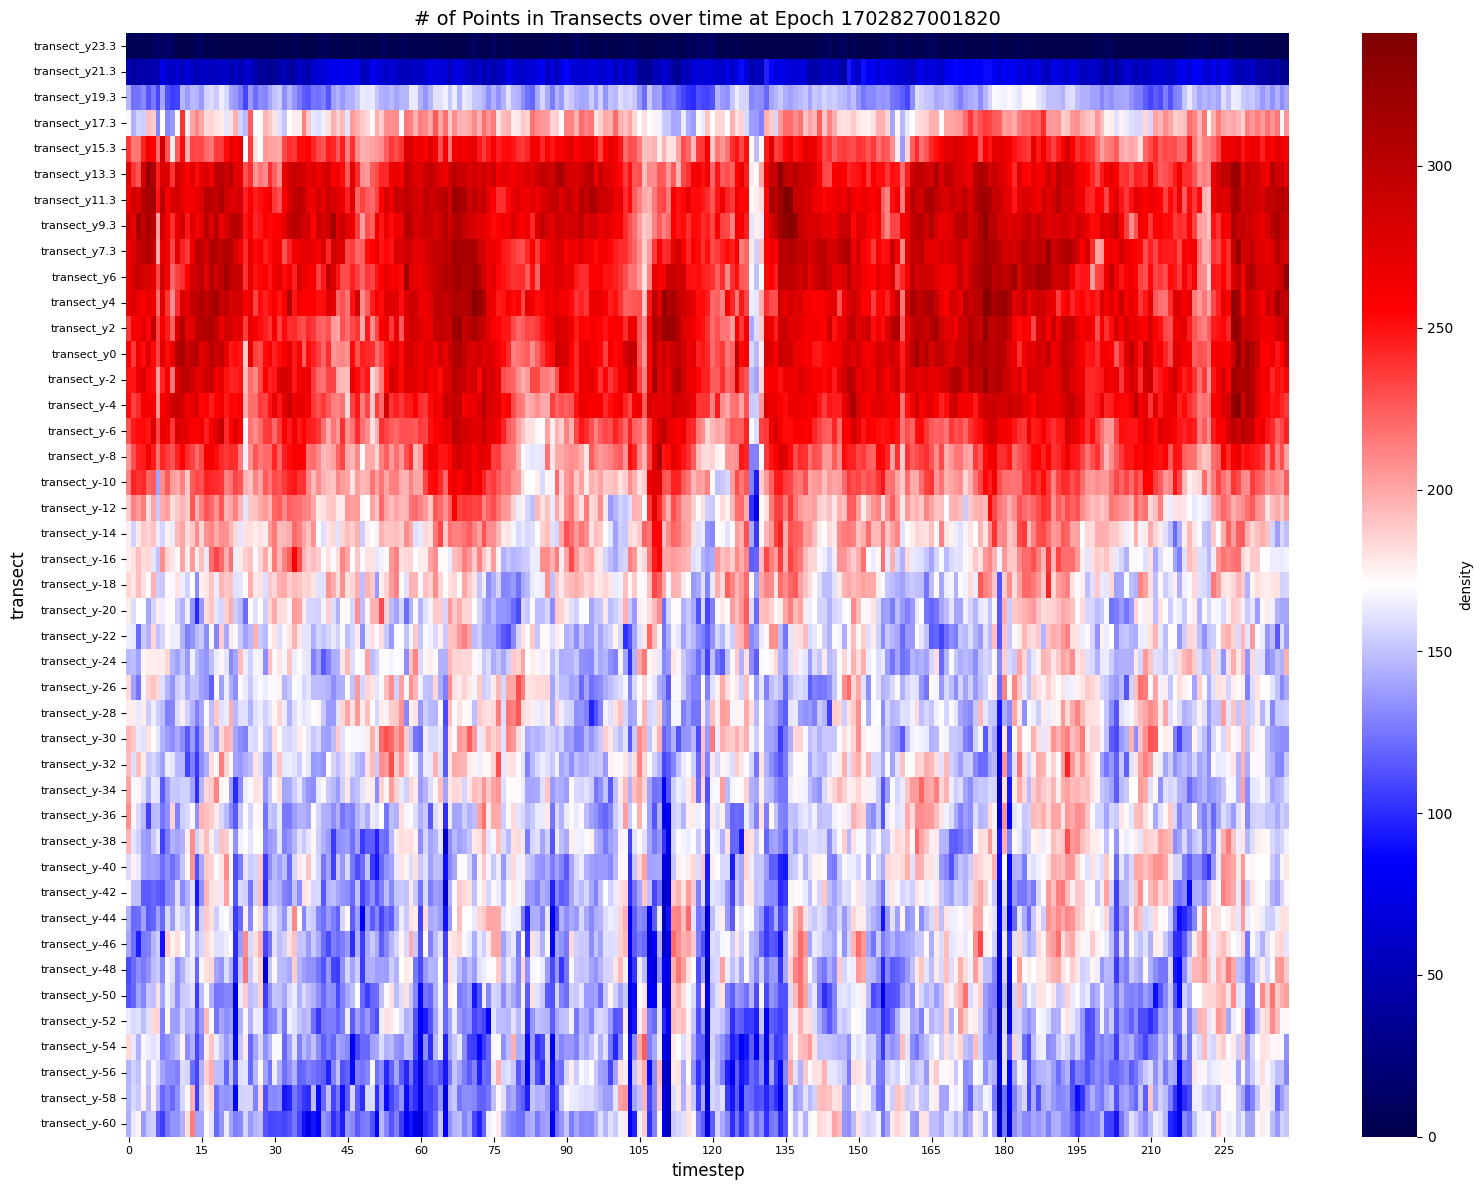

<Figure size 640x480 with 0 Axes>

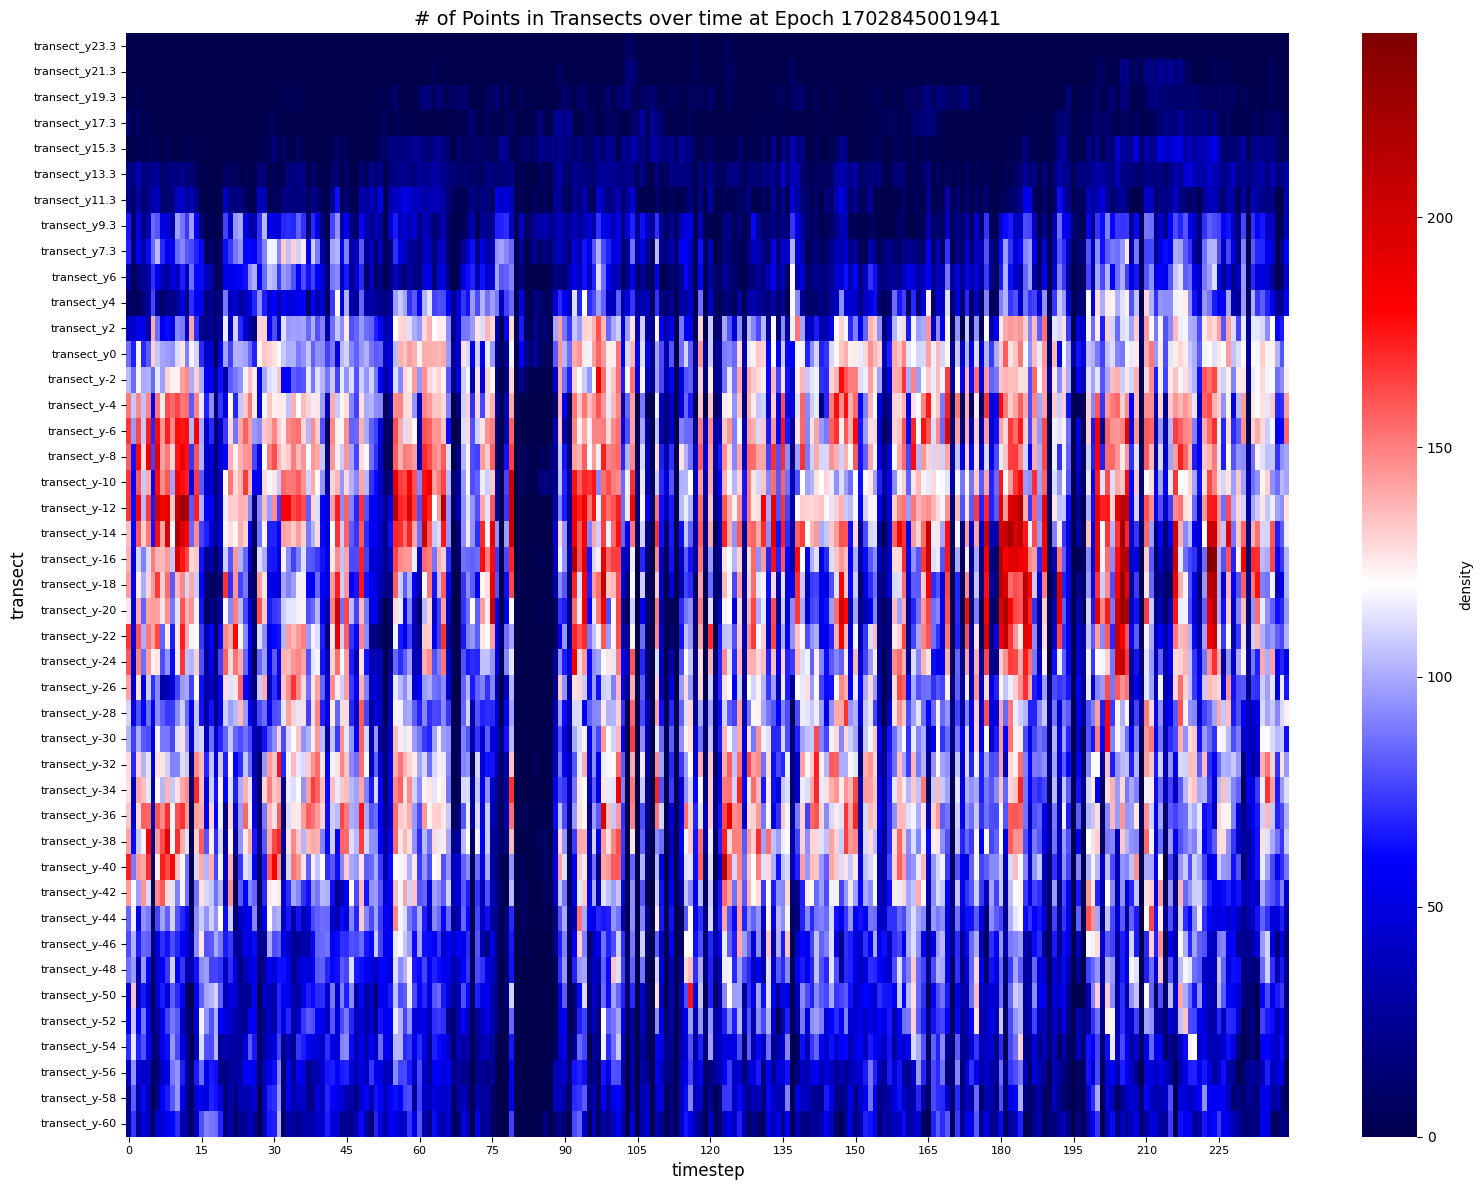

<Figure size 640x480 with 0 Axes>

In [42]:
pt_density_1820 = pd.DataFrame( {t_name: df.iloc[200:].count(axis=0) for t_name, df in sorted_1820.items()} ) 
pt_density_1941 = pd.DataFrame( {t_name: df.iloc[200:].count(axis=0) for t_name, df in sorted_1941.items()} ) 

plot_density(pt_density_1820,figpath1820,'1702827001820')
plot_density(pt_density_1941,figpath1941,'1702845001941')

Train model on red band of DEM (most dense transects: -12 to 16.3) exclude transect 7.3 for prediction

In [ ]:
savepath=os.join.path(savepath1820,'L2R_model_training/')
reconstructed_df,pipeline_history,stages_zoo,MAE_trained,window_size=train_MAE(
    ds=norm_tran1702827001820_nodune,
    exclude_tran='7.3',
    num_training=[-12,16.3],
    iterations=8,
    window_size=10,
    savepath=savepath,
    modelsavepath=modelsavepath)

apply trained model from epoch 1702827001820 to epoch 1702830601159 (whole DEM)

In [ ]:
def predict_transect(model,transect_df,window_size,stride=5):
    # apply the most recent pre-trained model onto a new transect to predict values
    current_dataset=transect_df.copy()
    active_mask=(~np.isnan(current_dataset)).astype(float)

    reconstructed_df=reconstruct_ds_with_MAE(model=model,current_df=current_dataset,active_mask_df=active_mask,window_size=window_size,stride=stride)
    return reconstructed_df
def predict_alongshore(model,ds,window_size,savepath):
    alongshore_predictions={}
    for t_name,df in ds.items():
        print(f"Predicting on transect: {t_name}")
        df_nodune=df.iloc[200:]

        reconstructed_df=predict_transect(model=model,transect_df=df_nodune,window_size=window_size,stride=5)
        alongshore_predictions[t_name]=pd.concat([df.iloc[:200],reconstructed_df],ignore_index=True)
        transect_savepath=os.path.join(savepath,"alongshore_pred_transect",str(t_name))
        os.makedirs(transect_savepath,exist_ok=True)
        print("video of reconstruction")
        save_stage_video_animation(orig_full_df=df, recon_no_dune_df=reconstructed_df,window_size=window_size,stage_dir=transect_savepath,interval=500)


    print("saving transect preidtions as csv")
    df_save=alongshore_predictions
    df_unnorm_save=unscale_dataframe(df_save,global_scaler)
    df_save.to_csv(os.path.join(savepath,f"alongshore_predictions_norm{str(t_name)}.csv"))
    df_unnorm_save.to_csv(os.path.join(savepath,f"alongshore_predictions{str(t_name)}.csv"))
     # add in DEM plotting?   
    return alongshore_predictions

In [ ]:
savepath=os.join.path(savepath1159,"L2R_predicted/from_MAE1820/")
predicted_transects_1159=predict_alongshore(model=MAE_trained,ds=sorted_1159,window_size=window_size,savepath=savepath)

Repeat on R2L model

In [ ]:
def define_R2L_functions():
    # this function trains defines the R2L model and the functions needed to train the model
    # define model
    # right now using a window length of 10 so need to build up back to 10, if size is a multiple of 8 it's much easier for building up
    class Denoise(Model):
        def __init__(self,window_size):
            super(Denoise,self).__init__()
            self.window_size=window_size

            self.encoder=tf.keras.Sequential([
                layers.Input(shape=(window_size,2)), # changed from none
                layers.Conv1D(32,3,activation='relu',padding='same',strides=2),
                layers.Conv1D(16,3,activation='relu',padding='same',strides=2),
                layers.Conv1D(8,3,activation='relu',padding='same',strides=2) #maintain shape with strides=1
            ])

            self.decoder=tf.keras.Sequential([
                layers.Conv1DTranspose(8,3,strides=2,activation='relu',padding='same'),
                layers.Conv1DTranspose(16,3,strides=2,activation='relu',padding='same'),
                layers.Conv1DTranspose(32,3,strides=2,activation='relu',padding='same'),
                layers.Flatten(),
                layers.Dense(window_size,activation='sigmoid'),
                layers.Reshape((window_size,1))
            ])

        def call(self,x):
            encoded=self.encoder(x)
            decoded=self.decoder(encoded)
            return decoded
    
        def train_step(self,data):
            # to get input tensor (x_input,y) from .map() in mask
            x_input,y, mask,start_idx,t_step = data #(batch,10,2) (batch,10,1) (batch,10,1)

            with tf.GradientTape() as tape: 
                # forward pass using x_masked
                y_pred=self(x_input,training=True)
                # calc loss
                mse=tf.square(y_pred-y) #calc loss
                masked_mse=mse*(1.0 - mask) # masked loss
                loss=tf.reduce_sum(masked_mse)/(tf.reduce_sum(1.0-mask)+1e-1)
               
            trainable_vars=self.trainable_variables
            gradients=tape.gradient(loss,trainable_vars)
            self.optimizer.apply_gradients(zip(gradients,trainable_vars))

            return{"loss":loss}
    
        def test_step(self,data):
            # to get input tensor
            x,y,mask,start_idx,t_step=data
            y_pred=self(x,training=False)

            mse=tf.square(y_pred-y) #calc loss
            masked_mse=mse*(1.0 - mask) # masked loss
            loss=tf.reduce_sum(masked_mse)/(tf.reduce_sum(1.0-mask)+1e-6) # mean sq error over just masked points

            return {"loss":loss}


    def gap_mask(x,mask_ratio):
        #batch_size=tf.shape(x)[0]
        length=tf.shape(x)[0]# number of things in x, x is (10,1)

        gap_size=tf.cast(tf.cast(length,tf.float32)*mask_ratio,tf.int32) # how many elements to be masked (length of window*maskratio)
        gap_size=tf.maximum(gap_size,1) # no zero lengths aka at least one thing is masked
        max_start=tf.maximum(length-gap_size,0) #mask starts inside window

        start=tf.random.uniform([],minval=0,maxval=max_start+1,dtype=tf.int32) # random start of mask
        range_idx=tf.range(length) # (length,) 

        #boolean mask
        if_in_gap=tf.logical_and(range_idx>=start,range_idx<(start+gap_size))

        gap_mask_tensor=tf.cast(if_in_gap,tf.float32)
        gap_mask_tensor=tf.expand_dims(gap_mask_tensor,-1) # 1 at gap, 0 everywhere else (batch,length,1)
        mask=1-gap_mask_tensor
        x_masked=x*mask
        return x_masked,mask

    def random_mask(x,mask_ratio):
        #batch=tf.shape(x)[0]
        #length=tf.shape(x)[1]
        #shape=[tf.shape(x)[0],tf.shape(x)[1],1] # list [batch,length,1]
        mask=tf.cast(tf.random.uniform(tf.shape(x))>mask_ratio,tf.float32) # mask is is (batch,length,1) and x_masked is (batch,length,2)
        x_masked=x*mask
        return x_masked, mask


    def masking_layer(x,start,t_step):
        #x=tf.expand_dims(x,axis=-1) if len(x.shape)==1 else x # (length,1)
        window_size=tf.shape(x)[0]
        x=tf.reshape(tf.cast(x,tf.float32),[window_size,1]) # 10 is window length
        mask_ratio=tf.random.uniform([],0.1,0.8) #mask possibilities of 10-80%

        use_gaps=tf.random.uniform([])<0.7 #random chosen number to use this mask method
        #mask via gap and random method
        x_masked,mask=tf.cond(use_gaps,lambda: gap_mask(x,mask_ratio),lambda: random_mask(x,mask_ratio))
        x_input=tf.concat([x_masked,mask],axis=-1) # now (1,length,2)

        return x_input,x, mask, start, t_step# (given data and target/real og data)
    
    def window_split_rtl(start, stop, window_size, overlap_stride):
        windows = []
    
        # Start at the absolute right-most possible window position
        current_start = stop - window_size
    
        # Loop backwards as long as the window doesn't cross the left 'start' boundary
        while current_start >= start:
            w_start = current_start
            w_stop = current_start + window_size
        
            # append as (start, stop) so indices read normally
            windows.append((w_start, w_stop))
        
            # Move the window stride to the left
            current_start -= overlap_stride
        return windows
    
    def find_windows_of_data(df, window_size, overlap_stride):
        # Find the continuous sections of data and extract window indices
        window_idx = {}
        for timestep, transect in df.items():
            arg = transect.values
            masked = np.ma.masked_invalid(arg)
            clumps = np.ma.clump_unmasked(masked)
            window_idx[timestep] = [(s.start, s.stop) for s in clumps]

        split_windows_idx = {}
        for timestep in window_idx:
            new_windows = []
            for (start, stop) in window_idx[timestep]:
                length = stop - start
                if length >= window_size:
                    # Modifying this call to ensure it processes from right to left
                    new_windows.extend(window_split_rtl(start, stop, window_size, overlap_stride))
            split_windows_idx[timestep] = new_windows

        return split_windows_idx
    
    def prep_training(train_source_df,split_windows_idx,batch_size=16):
        # windows of training/testing/vaidation data
        # run MAE training cycle per targeted window size
        timesteps=sorted(split_windows_idx.keys()) #chronological order
        n=len(timesteps)

        # train/val/test bounds
        train_end=int(n*0.7)
        val_end=int(n*0.85)

        train_time=timesteps[:train_end] #slice to grab train/test/val
        val_time=timesteps[train_end:val_end]
        test_time=timesteps[val_end:]

        def grab_windows(time_list): #loop through list of timesteps grab columnmand store as numpy vector
            X, info = [],[]
            for t in time_list:
                transect=train_source_df[t].values #grab from static training source
            
                for (start,stop) in split_windows_idx[t]: # windows of chosen size
                    X.append(transect[start:stop])
                    info.append({'timestep':t,'start':start,'stop':stop}) # store location to put back together
            return np.array(X, dtype="float32"), info
    
        X_train, info_train=grab_windows(train_time)
        X_val, info_val=grab_windows(val_time)
        X_test, info_test=grab_windows(test_time)

        # create ds function (mem efficient)
        def build_ds(X,info):
            starts=np.array([i['start'] for i in info]) # start points spatial
            tsteps=np.array([i['timestep'] for i in info]) # end points spatial
            ds=tf.data.Dataset.from_tensor_slices((X,starts,tsteps)) # arrays into TensorFlow tensor slice ds
            # mask over transect windows, process masks concureently, batches of 16, prep batch n+1 while working on current batch (efficiency)
            return (ds.map(masking_layer,num_parallel_calls=tf.data.AUTOTUNE).batch(batch_size,drop_remainder=True).prefetch(tf.data.AUTOTUNE))
    
        train_ds=build_ds(X_train,info_train)
        test_ds=build_ds(X_test,info_test)
        val_ds=build_ds(X_val,info_val)

        return train_ds, test_ds, val_ds
    def run_MAE(window_size,train_ds,val_ds, epochs=20):
        # inirialize model
        model=Denoise(window_size=window_size)
        #optimizer_tuned=Adam(learning_rate=1e-4)
        model.compile(optimizer='adam')

        #print(f"Training started for window size: {window_size} (train shape: {train_ds.shape})")
        history=model.fit(train_ds, validation_data=val_ds, epochs=epochs, verbose=1)
        return model, history
    def is_gap_too_big(mask,window_size):
        mask_str="".join(mask.astype(int).astype(str))
        return "0"*window_size in mask_str
    def reconstruct_ds_with_MAE(model, current_df, active_mask_df, window_size, stride=5):
        # slides MAE over the transects from left to right to impute where gaps exist
        # returns newly filled dataset
        x_matrix=tf.convert_to_tensor(current_df.values,dtype=tf.float32) # dataframe to tensorflow float 32
        transect_pts,tsteps=x_matrix.shape # length or cross-shore, timesteps

        mask_matrix=active_mask_df.values.astype(np.float32)
        #raw_groundtruth=baseline_raw_df.values

        reconstructed_all=[]

        for i in range(tsteps): # loop through every time step
            x_1dim=x_matrix[:,i].numpy() #current transect
            mask_1dim=mask_matrix[:,i] #gaps present in og or prev reconstrcution
            #raw_1dim=raw_groundtruth[:,i] #true og data

            full_recon=np.zeros_like(x_1dim) 
            counts=np.zeros_like(x_1dim)

            # slide window over full transect profile
            for start in range(0,transect_pts-window_size+1,stride):
                end=start+window_size

                #window_raw=raw_1dim[start:end] # window of raw data
                window_data=np.nan_to_num(x_1dim[start:end]) #slice of transect any nans to 0 current df
                window_mask=mask_1dim[start:end] #

                #model input shape
                combined_input=np.stack([window_data,window_mask],axis=-1).reshape(1,window_size,2) # transect slice with batch dim

                # check for too big of gap
                gap_too_big=is_gap_too_big(window_mask,window_size) 
                # check if window is full
                is_already_full = np.all(window_mask == 1.0)
                # check if the window has valid data on left and right edges
                has_bounded_edges = (window_mask[0] == 1.0) and (window_mask[-1] == 1.0)
                #double check there actually is a gap inside to fix (at least 1 point)
                has_gap_inside = np.any(window_mask == 0.0)

                # run MAE only if it's bounded on both sides
                if has_gap_inside and has_bounded_edges:
                    #predict with MAE
                    model_recon = model.predict(combined_input, verbose=0).flatten()
                    # keep original data
                    recon_window=np.where(window_mask==1.0,window_data,model_recon) # keep og data

                    #preds for avg
                    full_recon[start:end] = np.nansum([full_recon[start:end], recon_window], axis=0)
                    counts[start:end] += 1
            
                elif is_already_full:
                    #keep full window
                    full_recon[start:end] = np.nansum([full_recon[start:end], window_data], axis=0)
                    counts[start:end] += 1
            # trying to fix mismatch on gap edges
            raw_prediction=np.divide(full_recon,counts,out=np.full_like(full_recon,np.nan),where=counts>0)
            nan_indices=np.isnan(raw_prediction)
            raw_prediction[nan_indices]=x_1dim[nan_indices]

            final_transect=raw_prediction.copy()
            is_gap=(mask_1dim==0) # find gap
            gap_changes=np.diff(is_gap.astype(int))

            gap_starts=np.where(gap_changes==1)[0]+1
            gap_ends=np.where(gap_changes==-1)[0]

            # at the edge
            if is_gap[0]: gap_starts= np.insert(gap_starts,0,0)
            if is_gap[-1]: gap_ends=np.append(gap_ends,len(is_gap)-1)
            # smooth over transistion?
            blend_zone=min(4,int(window_size/4)) # transistion blending margin

            for g_start,g_end in zip(gap_starts,gap_ends):
                #left side blend
                if g_start>blend_zone:
                    anchor_val=x_1dim[g_start -1] #known real value
                    for b in range(blend_zone):
                        idx=g_start+b
                        if idx<= g_end:
                            # linear transition (Could do something better) from anchor to pred
                            alpha=(b+1)/(blend_zone +1)
                            final_transect[idx]=(1-alpha)*anchor_val+alpha*raw_prediction[idx]
                #right side
                if g_end< len(x_1dim)-blend_zone:
                    anchor_val=x_1dim[g_end+1]
                    for b in range(blend_zone):
                        idx=g_end-b
                        if idx>=g_start:
                            alpha=(b+1)/(blend_zone+1)
                            final_transect[idx]=(1-alpha)*anchor_val+alpha*raw_prediction[idx]

            # overide to keep og data
            final_transect=np.where(mask_1dim==1.0,x_1dim,final_transect)

            reconstructed_all.append(final_transect)
        # return dataframe (points, timesteps)
        return pd.DataFrame(np.stack(reconstructed_all,axis=1),columns=current_df.columns)
    def window_split(start,stop,size,overlap):
        return[(i,i+size) for i in range(start,stop-size+1,int(overlap))]
    
    def find_windows_of_data(df,window_size,overlap_stride):
        # find the continous sections of data and extract window indices
        window_idx={}
        for timestep,transect in df.items():
            arg=transect.values
            masked=np.ma.masked_invalid(arg)
            clumps=np.ma.clump_unmasked(masked)
            window_idx[timestep]=[(s.start,s.stop)for s in clumps]

        split_windows_idx={}
        for timestep in window_idx:
            new_windows=[]
            for (start,stop) in window_idx[timestep]:
                length=stop-start
                if length>= window_size:
                    new_windows.extend(window_split(start,stop,window_size,overlap_stride))
            split_windows_idx[timestep]=new_windows

        return split_windows_idx
    
    return {
        "Denoise": Denoise,
        "prep_training":prep_training,
        "run_MAE": run_MAE,
        "reconstruct_ds_with_MAE": reconstruct_ds_with_MAE,
        "find_windows_of_data": find_windows_of_data,
    }

In [ ]:
R2L_tools=define_R2L_functions()
Denoise=R2L_tools["Denoise"]
prep_training=R2L_tools["prep_training"]
run_MAE=R2L_tools["run_MAE"]
reconstruct_ds_with_MAE=R2L_tools["reconstruct_ds_with_MAE"]
find_windows_of_data=R2L_tools["find_windows_of_data"]

In [ ]:
def train_MAE(ds,exclude_tran,num_training,iterations,window_size,savepath,modelsavepath):
    # this model trains the Left to Right MAE model (L2R) with a specified number of iterations, a starting window size, 
    # specified number of training transects, and a transect(s) to exclude from training
    # INPUTS:
    # ----------------------------
    # ds = matrix of transects used for training
    # exclude_tran = name of transect to exclude
    # num_training = [start transect, end transect] transects to include in training
    # iterations = number of iterations to use in model training
    # window_size = starting window size of model training
    # savepath = where to save data & plots

    os.makedirs(savepath,exist_ok=True)

    # grab subset of training data from the transect ds
    if isinstance(num_training, (list,tuple)) and len(num_training) == 2:
        training_ds=ds.iloc[:,num_training[0]:num_training[1]].copy()
    else:
        training_ds=ds.copy()
    # exclude any transects specified
    if isinstance(exclude_tran,list):
        training_ds=training_ds.drop(columns=exclude_tran,errors="ignore")
        target_key=exclude_tran[0] if len(exclude_tran)>0 else None
    else: 
        training_ds=training_ds.drop(columns=[exclude_tran],errors="ignore")
        target_key=exclude_tran
    if target_key is not None and target_key in ds.columns:
        current_dataset=ds[[target_key]].copy()
    else:
        current_dataset=ds.copy()

    active_mask=(~np.isnan(current_dataset)).astype(float)
    historical_changes_zoo={}
    pipeline_history={}
    current_window_size=window_size
    trained_model=None

    # Iterative training
    for iteration in range(1,iterations+1):
        stage_name=f"stage_{iteration}_size_{current_window_size}"
        print(f"\n--- Iteration {iteration}/{iterations} | Window Size: {current_window_size} ---")
    # map of gaps in transect for training (where is there data)
    current_windows_idx=find_windows_of_data(training_ds,window_size=current_window_size,overlap_stride=int(current_window_size//2))
    # prep alongshore transect windows of given size (add in part where you grab inbtween windows) (training data)
    tf_train,tf_val,tf_test=prep_training(train_source_df=training_ds,split_windows_idx=current_windows_idx,batch_size=16)
    # run model
    trained_model,history=run_MAE(window_size=current_window_size,train_ds=tf_train,val_ds=tf_val,epochs=30)
    # reconstruct transect
    reconstructed_df=reconstruct_ds_with_MAE(model=trained_model,current_df=current_dataset,active_mask_df=active_mask,window_size=current_window_size,stride=5)
    
    # store results
    eval_windows_idx=find_windows_of_data(current_dataset,window_size=current_window_size, overlap_stride=int(current_window_size//2))# need for metrics (where are gaps)
    historical_stages_zoo[stage_name]=reconstructed_df.copy()
    print("plotting error and loss")
    save_stage_loss_plot(history=history,window_size=current_window_size,stage_dir=savepath)
    # save stats
    pipeline_history[current_window_size]={"model":trained_model,"history":history,"dataset_after_stage": reconstructed_df.copy()}
    print("plotting static timesteps")
    save_stage_comparison_plots(orig_full_df=transect_73, recon_no_dune_df=reconstructed_df,window_size=current_window_size,stage_dir=savepath)
    print("video of reconstruction")
    save_stage_video_animation(orig_full_df=transect_73, recon_no_dune_df=reconstructed_df,window_size=current_window_size,stage_dir=savepath,interval=500)
    # update for loop
    current_dataset=reconstructed_df
    active_mask=(~np.isnan(current_dataset)).astype(float)
    # check next window size up
    if iteration<iterations:
        floor=current_window_size+10
        current_mode=reeval_and_hist(active_mask_df=active_mask,min_length=floor,target_val=0,plot_histogram=True,stage_label=f"post {stage_name}")

    if current_mode is not None:
        if current_mode<=current_window_size:
            current_window_size=current_window_size+15
        else:
            current_window_size=int(current_mode)

    print(f"iteration done, moving to size {current_mode}")

    modelname="it2_L2R_MAE"
    modelpath=os.path.join(modelsavepath,f"{modelname}.keras")
    trained_model.save(modelpath)
    print(f"trained model saved to: {modelpath}")

    return current_dataset,pipeline_history,historical_changes_zoo,trained_model, current_window_size

In [ ]:
savepath=os.join.path(savepath1820,'R2L_model_training/')
reconstructed_df,pipeline_history,stages_zoo,MAE_trained,window_size=train_MAE(
    ds=norm_tran1702827001820_nodune,
    exclude_tran='7.3',
    num_training=[-12,16.3],
    iterations=8,
    window_size=10,
    savepath=savepath)

In [ ]:
savepath=os.join.path(savepath1159,"R2L_predicted/from_MAE1820/")
predicted_transects_1159=predict_alongshore(model=MAE_trained,ds=sorted_1159,window_size=window_size,savepath=savepath)

Repeat on aternating model

In [ ]:
def define_alt_functions():
    # define model
    # right now using a window length of 10 so need to build up back to 10, if size is a multiple of 8 it's much easier for building up
    class Denoise(Model):
        def __init__(self,window_size):
            super(Denoise,self).__init__()
            self.window_size=window_size

            self.encoder=tf.keras.Sequential([
                layers.Input(shape=(window_size,2)), # changed from none
                layers.Conv1D(32,3,activation='relu',padding='same',strides=2),
                layers.Conv1D(16,3,activation='relu',padding='same',strides=2),
                layers.Conv1D(8,3,activation='relu',padding='same',strides=2) #maintain shape with strides=1
            ])

            self.decoder=tf.keras.Sequential([
                layers.Conv1DTranspose(8,3,strides=2,activation='relu',padding='same'),
                layers.Conv1DTranspose(16,3,strides=2,activation='relu',padding='same'),
                layers.Conv1DTranspose(32,3,strides=2,activation='relu',padding='same'),
                layers.Flatten(),
                layers.Dense(window_size,activation='sigmoid'),
                layers.Reshape((window_size,1))
            ])

        def call(self,x):
            encoded=self.encoder(x)
            decoded=self.decoder(encoded)
            return decoded
    
        def train_step(self,data):
            # to get input tensor (x_input,y) from .map() in mask
            x_input,y, mask,start_idx,t_step = data #(batch,10,2) (batch,10,1) (batch,10,1)

            #x_input,mask=masking_layer(x) # apply mask
            #x_masked=x_input[:,:,:2]
            with tf.GradientTape() as tape: 
                # forward pass using x_masked
                y_pred=self(x_input,training=True)
                # calc loss
                #mask=x_input[:,:,1:2] #grab mask from 2nd channel
                mse=tf.square(y_pred-y) #calc loss
                masked_mse=mse*(1.0 - mask) # masked loss
                loss=tf.reduce_sum(masked_mse)/(tf.reduce_sum(1.0-mask)+1e-6) # mean sq error over just masked points

            trainable_vars=self.trainable_variables
            gradients=tape.gradient(loss,trainable_vars)
            self.optimizer.apply_gradients(zip(gradients,trainable_vars))

            return{"loss":loss}
    
        def test_step(self,data):
            # to get input tensor
            x,y,mask,start_idx,t_step=data
    
            y_pred=self(x,training=False)

            #mask=x_input[:,:,1:2]
            mse=tf.square(y_pred-y) #calc loss
            masked_mse=mse*(1.0 - mask) # masked loss
            loss=tf.reduce_sum(masked_mse)/(tf.reduce_sum(1.0-mask)+1e-6) # mean sq error over just masked points

            return {"loss":loss}


    def gap_mask(x,mask_ratio):
        #batch_size=tf.shape(x)[0]
        length=tf.shape(x)[0]# number of things in x, x is (10,1)

        gap_size=tf.cast(tf.cast(length,tf.float32)*mask_ratio,tf.int32) # how many elements to be masked (length of window*maskratio)
        gap_size=tf.maximum(gap_size,1) # no zero lengths aka at least one thing is masked
        max_start=tf.maximum(length-gap_size,0) #mask starts inside window

        start=tf.random.uniform([],minval=0,maxval=max_start+1,dtype=tf.int32) # random start of mask

        range_idx=tf.range(length) # (length,) 

        #boolean mask
        if_in_gap=tf.logical_and(range_idx>=start,range_idx<(start+gap_size))

        gap_mask_tensor=tf.cast(if_in_gap,tf.float32)
        gap_mask_tensor=tf.expand_dims(gap_mask_tensor,-1) # 1 at gap, 0 everywhere else (batch,length,1)
        mask=1-gap_mask_tensor
     
        x_masked=x*mask
        return x_masked,mask

    def random_mask(x,mask_ratio):
        #batch=tf.shape(x)[0]
        #length=tf.shape(x)[1]
        #shape=[tf.shape(x)[0],tf.shape(x)[1],1] # list [batch,length,1]
        mask=tf.cast(tf.random.uniform(tf.shape(x))>mask_ratio,tf.float32) # mask is is (batch,length,1) and x_masked is (batch,length,2)
        x_masked=x*mask
        return x_masked, mask


    def masking_layer(x,start,t_step):
        #x=tf.expand_dims(x,axis=-1) if len(x.shape)==1 else x # (length,1)
        window_size=tf.shape(x)[0]

        x=tf.reshape(tf.cast(x,tf.float32),[window_size,1]) # 10 is window length
        mask_ratio=tf.random.uniform([],0.1,0.8) #mask possibilities of 10-80%

        use_gaps=tf.random.uniform([])<0.7 #random chosen number to use this mask method
        #mask via gap and random method
        x_masked,mask=tf.cond(use_gaps,lambda: gap_mask(x,mask_ratio),lambda: random_mask(x,mask_ratio))

        x_input=tf.concat([x_masked,mask],axis=-1) # now (1,length,2)

        return x_input,x, mask, start, t_step# (given data and target/real og data)
    def is_gap_too_big(mask,window_size):
        mask_str="".join(mask.astype(int).astype(str))
        return "0"*window_size in mask_str
    
    def prep_training(train_source_df,split_windows_idx,batch_size=16):
        # windows of training/testing/vaidation data
        # run MAE training cycle per targeted window size
        timesteps=sorted(split_windows_idx.keys()) #chronological order
        n=len(timesteps)

        # train/val/test bounds
        train_end=int(n*0.7)
        val_end=int(n*0.85)

        train_time=timesteps[:train_end] #slice to grab train/test/val
        val_time=timesteps[train_end:val_end]
        test_time=timesteps[val_end:]

        def grab_windows(time_list): #loop through list of timesteps grab columnmand store as numpy vector
            X, info = [],[]
            for t in time_list:
                transect=train_source_df[t].values #grab from static training source
            
                for (start,stop) in split_windows_idx[t]: # windows of chosen size
                    X.append(transect[start:stop])
                    info.append({'timestep':t,'start':start,'stop':stop}) # store location to put back together
            return np.array(X, dtype="float32"), info
    
        X_train, info_train=grab_windows(train_time)
        X_val, info_val=grab_windows(val_time)
        X_test, info_test=grab_windows(test_time)

        # create ds function (mem efficient)
        def build_ds(X,info):
            starts=np.array([i['start'] for i in info]) # start points spatial
            tsteps=np.array([i['timestep'] for i in info]) # end points spatial
            ds=tf.data.Dataset.from_tensor_slices((X,starts,tsteps)) # arrays into TensorFlow tensor slice ds
            # mask over transect windows, process masks concureently, batches of 16, prep batch n+1 while working on current batch (efficiency)
            return (ds.map(masking_layer,num_parallel_calls=tf.data.AUTOTUNE).batch(batch_size,drop_remainder=True).prefetch(tf.data.AUTOTUNE))
    
        train_ds=build_ds(X_train,info_train)
        test_ds=build_ds(X_test,info_test)
        val_ds=build_ds(X_val,info_val)

        return train_ds, test_ds, val_ds
    
    def run_MAE(window_size,train_ds,val_ds, epochs=20):
        # inirialize model
        model=Denoise(window_size=window_size)
        #optimizer_tuned=Adam(learning_rate=1e-4)
        model.compile(optimizer='adam')

        #print(f"Training started for window size: {window_size} (train shape: {train_ds.shape})")
        history=model.fit(train_ds, validation_data=val_ds, epochs=epochs, verbose=1)
        return model, history
    
    def reconstruct_ds_with_MAE(model,current_df,active_mask_df,window_size,stride=5,direction='left2right'):
        # slides MAE over the transects alternating from left to right  and right to left to impute where gaps exist
        # returns newly filled dataset
        x_matrix=tf.convert_to_tensor(current_df.values,dtype=tf.float32) # dataframe to tensorflow float 32
        transect_pts,tsteps=x_matrix.shape # length or cross-shore, timesteps

        mask_matrix=active_mask_df.values.astype(np.float32)
        #raw_groundtruth=baseline_raw_df.values

        reconstructed_all=[]

        for i in range(tsteps): # loop through every time step
            x_1dim=x_matrix[:,i].numpy() #current transect
            mask_1dim=mask_matrix[:,i] #gaps present in og or prev reconstrcution

            valid_indices=np.where(mask_1dim==1.0)[0]
            if len(valid_indices)>0:
                last_valid_index=valid_indices[-1]
            else:
                last_valid_index=-1

            full_recon=np.zeros_like(x_1dim) 
            counts=np.zeros_like(x_1dim)
            #slide window over full transect
            for start in range(0,transect_pts-window_size+1,stride):
                end=start+window_size
                window_data=np.nan_to_num(x_1dim[start:end]) #any nans to 0
                window_mask=mask_1dim[start:end]

                if direction =='right2left':
                    pred_window_data=np.flip(window_data)
                    pred_window_mask=np.flip(window_mask)
                else:
                    pred_window_data=window_data
                    pred_window_mask=window_mask

                combined_input=np.stack([pred_window_data,pred_window_mask],axis=-1).reshape(1,window_size,2)

                # CHECKS
                is_already_full = np.all(window_mask == 1.0) # check if window is full
                has_gap_inside = np.any(window_mask == 0.0) #double check there actually is a gap inside to fix (at least 1 point)

                if is_already_full:# PATH1: do not predict if full of data
                    #keep full window
                    full_recon[start:end] = np.nansum([full_recon[start:end], window_data], axis=0)
                    counts[start:end] += 1
                    continue

                if has_gap_inside:
                    gap_indices=np.where(window_mask==0.0)[0]
                    total_real_data_pts=np.sum(window_mask==1.0)
                    min_context_pts=1 #threshold of at least one point
                    has_any_local_context=total_real_data_pts>=min_context_pts

                    full_gap_idx=start+gap_indices[0]
                    g_start=full_gap_idx
                    if is_gap_too_big(window_mask,window_size=window_size):
                        #g_start=full_gap_idx
                        while g_start>0 and mask_1dim[g_start-1]==0.0:
                            g_start-=1
                        g_end=start+gap_indices[-1]
                        while g_end<transect_pts-1 and mask_1dim[g_end+1]==0.0:
                            g_end+=1
                        gap_size=g_end - g_start +1
                        print(f"gap size is {gap_size}")
                        if gap_size > window_size: # gap too big (outside of window)
                            print(f"t index {i} skipped gap ({start}:{end}) too large")
                            continue

                has_bounds=(window_mask[0]==1.0) and (window_mask[-1]==1.0)
                left_bound=(window_mask[0]==1.0) or (start>0 and mask_1dim[start-1]==1.0) #or (start==0)
                right_bound=(window_mask[-1]==1.0) or (end<transect_pts and mask_1dim[end]==1) #or (end==transect_pts)
                both_sides_bounded=left_bound or right_bound
                is_bounded=both_sides_bounded or has_bounds

                if has_any_local_context and is_bounded:
                    model_recon = model.predict(combined_input, verbose=0).flatten()
                    if direction=='right2left':
                        model_recon=np.flip(model_recon) # flip back
                        # keep original data
                    recon_window=np.where(window_mask==1.0,window_data,model_recon) # keep og data
                        #preds for avg
                        #pred_only_window=np.where(window_mask==0.0,model_recon,0.0)
                    full_recon[start:end] = np.nansum([full_recon[start:end], recon_window], axis=0)
                    counts[start:end] += (window_mask==0.0).astype(float) # this only increments up where there are actual gap

            raw_prediction=np.divide(full_recon,counts,out=np.full_like(full_recon,np.nan),where=counts>0) # combine any overlapping predictions
            nan_indices=np.isnan(raw_prediction) # where gaps are missed bc at edge or too big of window

            # get rid of prediction into the abysss
            if last_valid_index !=-1 and last_valid_index<len(raw_prediction)-1:
                raw_prediction[last_valid_index+1:]=np.nan

            final_transect=raw_prediction.copy()
            is_gap=(mask_1dim==0) # find gap
            gap_changes=np.diff(is_gap.astype(int))

            gap_starts=np.where(gap_changes==1)[0]+1
            gap_ends=np.where(gap_changes==-1)[0]
            # at the edge
            if is_gap[0]: gap_starts= np.insert(gap_starts,0,0)
            if is_gap[-1]: gap_ends=np.append(gap_ends,len(is_gap)-1)
            # smooth over transistion (2-4 data points of smoothing with favor to the real data)
            blend_zone=min(4,int(window_size/4)) # transistion blending margin
            for g_start,g_end in zip(gap_starts,gap_ends):
                current_gap_size=g_end-g_start+1
                if current_gap_size<=6: # don't blend over the small gaps
                    continue
                #left side blend
                if g_start>blend_zone:
                    anchor_val=x_1dim[g_start -1] #known real value
                    for b in range(blend_zone):
                        idx=g_start+b
                        if idx<= g_end and not np.isnan(raw_prediction[idx]):
                            # linear transition (Could do something better) from anchor to pred
                            alpha=(b+1)/(blend_zone +1)
                            final_transect[idx]=(1-alpha)*anchor_val+alpha*raw_prediction[idx]
                #right side
                if g_end< len(x_1dim)-1:
                    right_anchor_idx=min(len(x_1dim)-1,g_end+1)
                    if mask_1dim[right_anchor_idx]==1.0: 
                        anchor_val=x_1dim[g_end+1]
                        for b in range(blend_zone):
                            idx=g_end-b
                            if idx>=g_start and not np.isnan(raw_prediction[idx]):
                                alpha=(b+1)/(blend_zone+1)
                                final_transect[idx]=(1-alpha)*anchor_val+alpha*raw_prediction[idx]
            # overide to keep og data (kind of like a fail safe if the rest didn't work)
            final_transect=np.where(mask_1dim==1.0,x_1dim,final_transect)
            #plot_timestep_reconstruction(x_1dim, mask_1dim, full_recon, counts, final_transect, timestep_idx=i) # plot for debugging
            reconstructed_all.append(final_transect)
        # return dataframe (points, timesteps)
        return pd.DataFrame(np.stack(reconstructed_all,axis=1),columns=current_df.columns)
    return {
        "Denoise": Denoise,
        "prep_training":prep_training,
        "run_MAE": run_MAE,
        "reconstruct_ds_with_MAE": reconstruct_ds_with_MAE,
        "find_windows_of_data": find_windows_of_data,
    }

In [ ]:
alt_tools=define_alt_functions()
Denoise=alt_tools["Denoise"]
prep_training=alt_tools["prep_training"]
run_MAE=alt_tools["run_MAE"]
reconstruct_ds_with_MAE=alt_tools["reconstruct_ds_with_MAE"]
find_windows_of_data=alt_tools["find_windows_of_data"]

In [ ]:
def train_MAE(ds,exclude_tran,num_training,iterations,window_size,savepath,modelsavepath):
    # this model trains the Left to Right MAE model (L2R) with a specified number of iterations, a starting window size, 
    # specified number of training transects, and a transect(s) to exclude from training
    # INPUTS:
    # ----------------------------
    # ds = matrix of transects used for training
    # exclude_tran = name of transect to exclude
    # num_training = [start transect, end transect] transects to include in training
    # iterations = number of iterations to use in model training
    # window_size = starting window size of model training
    # savepath = where to save data & plots

    os.makedirs(savepath,exist_ok=True)

    # grab subset of training data from the transect ds
    if isinstance(num_training, (list,tuple)) and len(num_training) == 2:
        training_ds=ds.iloc[:,num_training[0]:num_training[1]].copy()
    else:
        training_ds=ds.copy()
    # exclude any transects specified
    if isinstance(exclude_tran,list):
        training_ds=training_ds.drop(columns=exclude_tran,errors="ignore")
        target_key=exclude_tran[0] if len(exclude_tran)>0 else None
    else: 
        training_ds=training_ds.drop(columns=[exclude_tran],errors="ignore")
        target_key=exclude_tran
    if target_key is not None and target_key in ds.columns:
        current_dataset=ds[[target_key]].copy()
    else:
        current_dataset=ds.copy()

    active_mask=(~np.isnan(current_dataset)).astype(float)
    historical_changes_zoo={}
    pipeline_history={}
    current_window_size=window_size
    trained_model=None

    # Iterative training
    for iteration in range(1,iterations+1):
        stage_name=f"stage_{iteration}_size_{current_window_size}"
        print(f"\n--- Iteration {iteration}/{iterations} | Window Size: {current_window_size} ---")
    # map of gaps in transect for training (where is there data)
    current_windows_idx=find_windows_of_data(training_ds,window_size=current_window_size,overlap_stride=int(current_window_size//2))
    # prep alongshore transect windows of given size (add in part where you grab inbtween windows) (training data)
    tf_train,tf_val,tf_test=prep_training(train_source_df=training_ds,split_windows_idx=current_windows_idx,batch_size=16)
    # run model
    trained_model,history=run_MAE(window_size=current_window_size,train_ds=tf_train,val_ds=tf_val,epochs=30)
    # reconstruct transect
    reconstructed_df=reconstruct_ds_with_MAE(model=trained_model,current_df=current_dataset,active_mask_df=active_mask,window_size=current_window_size,stride=5)
    
    # store results
    eval_windows_idx=find_windows_of_data(current_dataset,window_size=current_window_size, overlap_stride=int(current_window_size//2))# need for metrics (where are gaps)
    historical_stages_zoo[stage_name]=reconstructed_df.copy()
    print("plotting error and loss")
    save_stage_loss_plot(history=history,window_size=current_window_size,stage_dir=savepath)
    # save stats
    pipeline_history[current_window_size]={"model":trained_model,"history":history,"dataset_after_stage": reconstructed_df.copy()}
    print("plotting static timesteps")
    save_stage_comparison_plots(orig_full_df=transect_73, recon_no_dune_df=reconstructed_df,window_size=current_window_size,stage_dir=savepath)
    print("video of reconstruction")
    save_stage_video_animation(orig_full_df=transect_73, recon_no_dune_df=reconstructed_df,window_size=current_window_size,stage_dir=savepath,interval=500)
    # update for loop
    current_dataset=reconstructed_df
    active_mask=(~np.isnan(current_dataset)).astype(float)
    # check next window size up
    if iteration<iterations:
        floor=current_window_size+10
        current_mode=reeval_and_hist(active_mask_df=active_mask,min_length=floor,target_val=0,plot_histogram=True,stage_label=f"post {stage_name}")

    if current_mode is not None:
        if current_mode<=current_window_size:
            current_window_size=current_window_size+15
        else:
            current_window_size=int(current_mode)

    print(f"iteration done, moving to size {current_mode}")

    modelname="it2_L2R_MAE"
    modelpath=os.path.join(modelsavepath,f"{modelname}.keras")
    trained_model.save(modelpath)
    print(f"trained model saved to: {modelpath}")

    return current_dataset,pipeline_history,historical_changes_zoo,trained_model,current_window_size

In [ ]:
savepath=os.join.path(savepath1820,'alt_model_training/')
reconstructed_df,pipeline_history,stages_zoo,MAE_trained,window_size=train_MAE(
    ds=norm_tran1702827001820_nodune,
    exclude_tran='7.3',
    num_training=[-12,16.3],
    iterations=8,
    window_size=10,
    savepath=savepath)

In [ ]:
savepath=os.join.path(savepath1159,"alt_predicted/from_MAE1820/")
predicted_transects_1159=predict_alongshore(model=MAE_trained,ds=sorted_1159,window_size=window_size,savepath=savepath)